In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../../../Data/HousingData.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
df.dropna(inplace=True)

In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 🎯 RandomizedSearchCV Parameters

### **estimator** `estimator object`

The base model used for training:

* Must follow the **scikit-learn estimator interface**
* Should implement:

  * `fit()` method
  * `score()` method *(or provide a `scoring` parameter)*

---

### **param_distributions** `dict or list of dicts`

Defines the parameter search space:

* **dict** → `{param_name: distribution or list}`
* **list of dicts** → Randomly selects one dictionary, then samples from it

Sampling behavior:

* **Distribution** → Must have `.rvs()` (e.g., from `scipy.stats`)
* **List** → Sampled uniformly

---

### **n_iter** `int` *(default = 10)*

Number of parameter combinations sampled:

* Higher → Better results, slower runtime
* Lower → Faster, less optimal

---

### **scoring** `str, callable, list, tuple, or dict` *(default = None)*

Evaluation metric(s) for model performance:

#### Single metric:

* String (e.g., `"accuracy"`, `"f1"`)
* Callable function
* `None` → Uses estimator’s default `.score()`

#### Multiple metrics:

* List/tuple of metric names
* Callable returning a dictionary
* Dictionary `{metric_name: function}`

---

### **n_jobs** `int` *(default = None)*

Controls parallel processing:

* **None** → 1 CPU
* **-1** → Use all CPUs

---

### **refit** `bool, str, or callable` *(default = True)*

Refits model on full dataset using best parameters:

* **True** → Refit using best score
* **str** → Use specific metric (for multi-metric case)
* **callable** → Custom selection logic

After refit:

* Best model → `best_estimator_`
* Best params → `best_params_`

---

### **cv** `int, CV generator, or iterable` *(default = None)*

Cross-validation strategy:

* **None** → 5-fold CV
* **int** → Number of folds
* **CV object** → Custom splitter
* **iterable** → Custom train/test splits

Behavior:

* Classification → **StratifiedKFold**
* Others → **KFold**

---

### **verbose** `int`

Controls logging output:

* `>1` → Shows computation time
* `>2` → Shows scores
* `>3` → Shows fold & parameter details

---

### **pre_dispatch** `int or str` *(default = "2*n_jobs")*

Controls number of parallel jobs dispatched:

* **None** → All jobs created immediately
* **int** → Fixed number of jobs
* **str** → Expression (e.g., `"2*n_jobs"`)

---

### **random_state** `int or RandomState` *(default = None)*

Controls randomness:

* Ensures reproducibility when fixed

---

### **error_score** `“raise” or numeric` *(default = np.nan)*

Handling errors during training:

* **"raise"** → Throws error
* **numeric** → Assigns value and raises warning

---

### **return_train_score** `bool` *(default = False)*

Whether to include training scores:

* **True** → Helps analyze overfitting
* **False** → Faster computation

---

In [6]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Parameter Tuning

In [7]:
from sklearn.model_selection import RandomizedSearchCV

reg = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(),
    param_distributions={
        "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
        "max_depth": list(range(1,101,5)),
        'splitter':['best', 'random'],
        'max_features': [0.25,0.5,1.0],
        'min_samples_split': list(range(2,51,5)),
        'min_samples_leaf': list(range(2,51,5))
    },
    cv=5,
    n_jobs=1,
    verbose=2,
    scoring='r2',
    n_iter=10
)

In [8]:
reg.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END criterion=absolute_error, max_depth=71, max_features=0.5, min_samples_leaf=37, min_samples_split=42, splitter=random; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=71, max_features=0.5, min_samples_leaf=37, min_samples_split=42, splitter=random; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=71, max_features=0.5, min_samples_leaf=37, min_samples_split=42, splitter=random; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=71, max_features=0.5, min_samples_leaf=37, min_samples_split=42, splitter=random; total time=   0.0s
[CV] END criterion=absolute_error, max_depth=71, max_features=0.5, min_samples_leaf=37, min_samples_split=42, splitter=random; total time=   0.0s
[CV] END criterion=poisson, max_depth=6, max_features=1.0, min_samples_leaf=17, min_samples_split=32, splitter=random; total time=   0.0s
[CV] END criterion=poisson, max_depth=6, max_features=1.0, min_samples_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 6, ...], 'max_features': [0.25, 0.5, ...], 'min_samples_leaf': [2, 7, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

In [9]:
print(reg.best_score_, reg.best_params_)

0.7600550948394538 {'splitter': 'random', 'min_samples_split': 32, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 81, 'criterion': 'friedman_mse'}


In [10]:
dt = reg.best_estimator_
y_pred = dt.predict(X_test)
r2_score(y_test, y_pred)

0.6240691954645854

In [13]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(dt,X,y,scoring='r2',cv=5))

np.float64(0.17931351395857392)

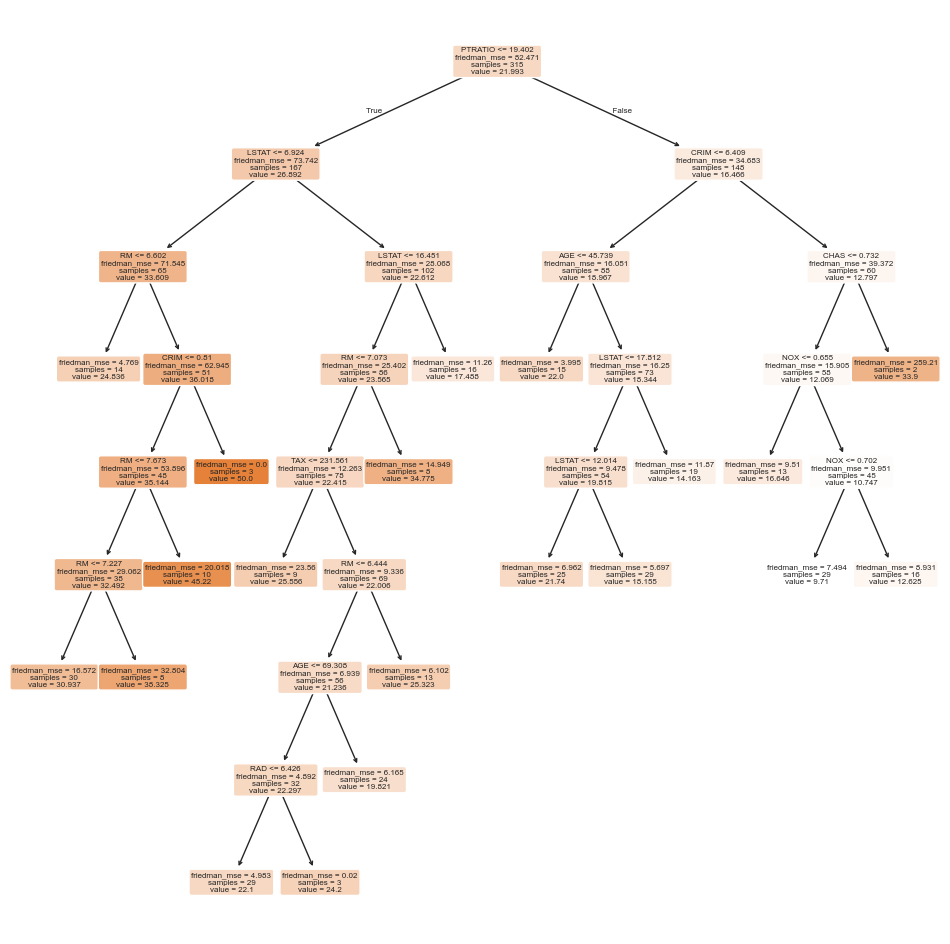

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,12))
plot_tree(dt, filled=True, feature_names=X.columns, rounded=True)
plt.show()